### What are the most demanded skills for the top three data roles in the United States?

This analysis identifies the three most common data roles in the U.S. dataset and compares the skills most frequently requested in their job postings.

#### Method
1. Filter job postings to the United States.
2. Expand the `job_skills` lists into individual skill rows.
3. Count skill occurrences by job role.
4. Identify the three most common roles.
5. Convert skill counts to percentages of postings for each role.
6. Compare the five most demanded skills for each role.

In [1]:
#importing libraries
import pandas as pd
import matplotlib.pyplot as plt
import ast
#from datetime import datetime
import seaborn as sns

#loading data
df = pd.read_csv('data_jobs.csv')
df.head(2)

#cleaning data
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
type(df['job_posted_date'][3])
df['job_skills'] = df['job_skills'].apply(lambda skill_list:ast.literal_eval(skill_list) if pd.notna(skill_list) else skill_list)
type(df['job_skills'][3])

list

In [2]:
# Focus on US job postings due to the large sample size
df.info()
df_US = df[df['job_country']=='United States']

<class 'pandas.DataFrame'>
RangeIndex: 785741 entries, 0 to 785740
Data columns (total 17 columns):
 #   Column                 Non-Null Count   Dtype         
---  ------                 --------------   -----         
 0   job_title_short        785741 non-null  str           
 1   job_title              785740 non-null  str           
 2   job_location           784696 non-null  str           
 3   job_via                785733 non-null  str           
 4   job_schedule_type      773074 non-null  str           
 5   job_work_from_home     785741 non-null  bool          
 6   search_location        785741 non-null  str           
 7   job_posted_date        785741 non-null  datetime64[us]
 8   job_no_degree_mention  785741 non-null  bool          
 9   job_health_insurance   785741 non-null  bool          
 10  job_country            785692 non-null  str           
 11  salary_rate            33067 non-null   str           
 12  salary_year_avg        22003 non-null   float64       


In [3]:
# Expand each skill list so that each skill occupies its own row    

df_skills = df_US.explode('job_skills')

df_skills[['job_title', 'job_skills']]

,job_title,job_skills
0,Senior Clinical Data Engineer / Principal Clin...,NaN
3,LEAD ENGINEER - PRINCIPAL ANALYST - PRINCIPAL ...,python
3,LEAD ENGINEER - PRINCIPAL ANALYST - PRINCIPAL ...,c++
3,LEAD ENGINEER - PRINCIPAL ANALYST - PRINCIPAL ...,java
3,LEAD ENGINEER - PRINCIPAL ANALYST - PRINCIPAL ...,matlab
...,...,...
785692,Data Scientist- Hybrid Work Location,r
785703,Data Analyst - CRYPTOGRAPHY - Full-time,NaN
785705,Expert Business Data Analyst - Now Hiring,sql
785705,Expert Business Data Analyst - Now Hiring,python


In [4]:

# Group by job_skills and job_title_short and count the number of occurrences
df_skills_count = df_skills.groupby(['job_skills', 'job_title_short']).size()

# Name the count column as count
df_skills_count = df_skills_count.reset_index(name='skill_count')

# Sort the values by skill_count in descending order
df_skills_count.sort_values(by='skill_count', ascending=False, inplace=True)

df_skills_count.head()



,job_skills,job_title_short,skill_count
1209,python,Data Scientist,42379
1521,sql,Data Analyst,34452
1523,sql,Data Scientist,30034
455,excel,Data Analyst,27519
1243,r,Data Scientist,26022


In [5]:
#creating list of top 3 roles
#job_titles = df_skills_count['job_title_short'].unique().tolist()

job_titles = (
    df_US['job_title_short']
    .value_counts()
    .head(3)
    .index
    .tolist()
)

job_titles = sorted(job_titles)

job_titles

['Data Analyst', 'Data Engineer', 'Data Scientist']

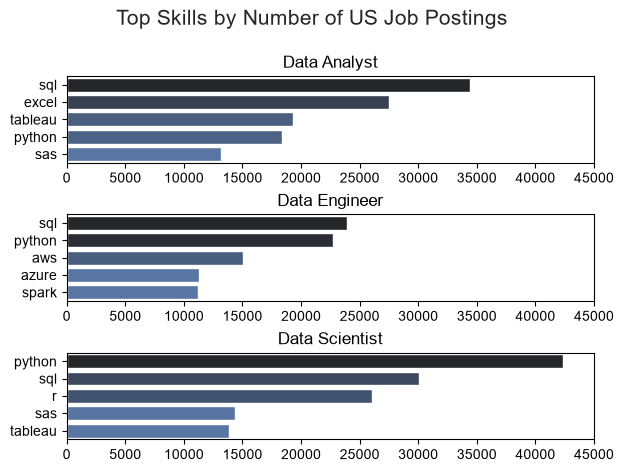

In [6]:
#plotting 
fig,ax = plt.subplots(3,1)
sns.set_theme(style='ticks')

for i, job_title in enumerate(job_titles):
    df_plot = df_skills_count[df_skills_count['job_title_short'] == job_title].head(5)
    sns.barplot(data=df_plot, x='skill_count', y='job_skills', ax=ax[i], hue='skill_count', palette='dark:b_r')
    ax[i].set_title(job_title)
    ax[i].set_ylabel('')
    ax[i].set_xlabel('')
    ax[i].get_legend().remove()
    ax[i].set_xlim(0, 45000) # make the scales the same

fig.suptitle('Top Skills by Number of US Job Postings',fontsize=15)
plt.tight_layout(h_pad = 0.5)
plt.show()



### Convert Counts to Percentages

### Convert Skill Counts to Percentages

To compare skill demand across roles with different numbers of job postings, calculate each skill's share of total postings for that role.

In [7]:

# Use original df to get the count of job titles
df_job_title_count = df_US['job_title_short'].value_counts().reset_index(name='jobs_total')

df_job_title_count.head()

,job_title_short,jobs_total
0,Data Analyst,67816
1,Data Scientist,58830
2,Data Engineer,35080
3,Senior Data Scientist,12946
4,Senior Data Analyst,11791


In [8]:
df_skills_perc = pd.merge(df_skills_count, df_job_title_count, on='job_title_short', how='left')

df_skills_perc['skill_percent'] = (df_skills_perc['skill_count'] / df_skills_perc['jobs_total']) * 100

df_skills_perc.head()

,job_skills,job_title_short,skill_count,jobs_total,skill_percent
0,python,Data Scientist,42379,58830,72.036376
1,sql,Data Analyst,34452,67816,50.802171
2,sql,Data Scientist,30034,58830,51.052184
3,excel,Data Analyst,27519,67816,40.578919
4,r,Data Scientist,26022,58830,44.232534


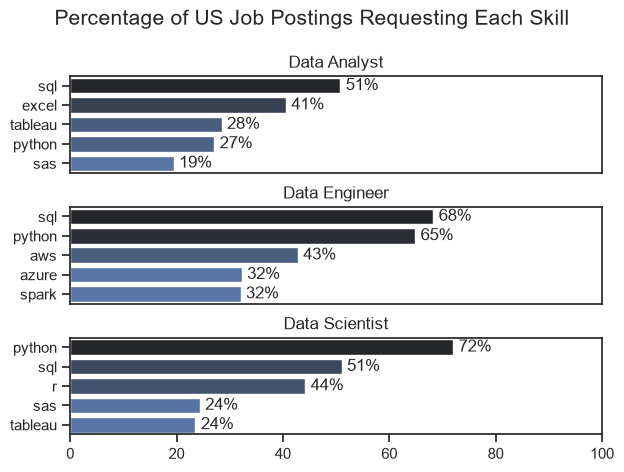

In [10]:
fig, ax = plt.subplots(len(job_titles), 1)

for i, job_title in enumerate(job_titles):
    df_plot = df_skills_perc[df_skills_perc['job_title_short'] == job_title].head(5)
    sns.barplot(data=df_plot, x='skill_percent', y='job_skills', ax=ax[i], hue='skill_percent', palette='dark:b_r')
    ax[i].set_title(job_title)
    ax[i].set_ylabel('')
    ax[i].set_xlabel('')
    ax[i].get_legend().remove()
    ax[i].set_xlim(0, 100)
    # remove the x-axis tick labels for better readability
    if i != len(job_titles) - 1:
        ax[i].set_xticks([])

    # label the percentage on the bars
    for n, v in enumerate(df_plot['skill_percent']):
        ax[i].text(v + 1, n, f'{v:.0f}%', va='center')

fig.suptitle('Percentage of US Job Postings Requesting Each Skill', fontsize=15)
fig.tight_layout(h_pad=.8)
plt.savefig(
    'images/1_skill_demand_Percentage of US Job Postings Requesting Each Skill.png',
    bbox_inches='tight',
    dpi=300
)
plt.show()